# TP1 — Part 3: CNNs + Data Augmentation on MNIST (Rotation & Translation)

**Course:** Deep Learning for Image Analysis / Computer Vision  
**Goal:** Train a **CNN** on MNIST, **inspect its layers**, and show how **data augmentation** (rotation + translation) can improve robustness.

In Part 2, we used an MLP and **flattened** images into vectors.  
In Part 3, we use **CNNs** to exploit spatial structure **(1, 28, 28)** and we test a key idea in vision:  
> If we train with rotated/translated images, the model generalizes better to these transformations.

---
## What you will do
1. Train a baseline CNN on MNIST (no augmentation)
2. Train the same CNN with **RandomAffine** augmentation (rotation + translation)
3. Compare test accuracy on:
   - **standard MNIST test**
   - **transformed MNIST test** (rotated/translated)
---


## 0) Setup (Colab GPU)

In Colab: **Runtime → Change runtime type → GPU**  
Then run the cell below.


In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: Tesla T4


## 1) Imports

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt


## 2) Data: MNIST + Augmentations

We will create **four** dataset variants:

1. **Train (no aug)**: standard MNIST training set  
2. **Train (aug)**: MNIST with *rotation + translation*
3. **Test (standard)**: standard MNIST test set  
4. **Test (transformed)**: MNIST test set **with the same types of transforms** (to evaluate robustness)

### Augmentation used
- Rotation: up to ±35 degrees
- Translation: up to 30% of the image size

This simulates real-world variation (digits rarely appear perfectly centered).


In [3]:
import torch
from torchvision import datasets, transforms

torch.manual_seed(0)

# Standard transform (no augmentation)
tfm_standard = transforms.ToTensor()

# Augmentation: rotation (±35°) + translation (up to 30%)
tfm_aug = transforms.Compose([
    transforms.RandomAffine(
        degrees=35,
        translate=(0.3, 0.3)
    ),
    transforms.ToTensor()
])

# "Transformed test" (same transforms, but deterministic randomness is fine for robustness eval)
tfm_test_transformed = transforms.Compose([
    transforms.RandomAffine(
        degrees=35,
        translate=(0.3, 0.3)
    ),
    transforms.ToTensor()
])

# Datasets
train_noaug = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=tfm_standard
)

train_aug = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=tfm_aug
)

test_std = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=tfm_standard
)

test_trans = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=tfm_test_transformed
)

len(train_noaug), len(train_aug), len(test_std), len(test_trans)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 692kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.72MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.95MB/s]


(60000, 60000, 10000, 10000)

### Quick visualization (standard vs augmented)

If augmentation is working, you should see digits slightly rotated and shifted.


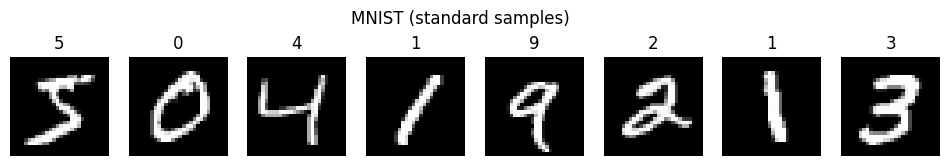

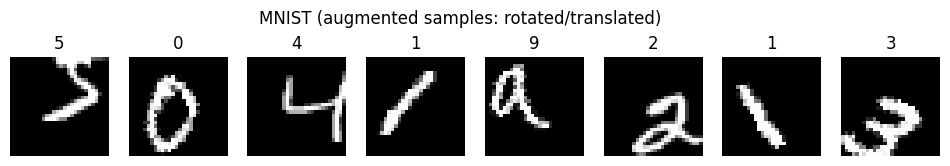

In [4]:
def show_samples(dataset, title, n=8):
    plt.figure(figsize=(12, 2))
    for i in range(n):
        img, label = dataset[i]
        plt.subplot(1, n, i+1)
        plt.imshow(img.squeeze(0), cmap="gray")
        plt.title(str(label))
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_samples(train_noaug, "MNIST (standard samples)")
show_samples(train_aug, "MNIST (augmented samples: rotated/translated)")


## 3) DataLoaders

We'll use mini-batches. If you run out of memory, reduce `batch_size`.


In [5]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader_noaug = DataLoader(
    train_noaug,
    batch_size=batch_size,
    shuffle=True
)

train_loader_aug = DataLoader(
    train_aug,
    batch_size=batch_size,
    shuffle=True
)

test_loader_std = DataLoader(
    test_std,
    batch_size=batch_size,
    shuffle=False
)

test_loader_trans = DataLoader(
    test_trans,
    batch_size=batch_size,
    shuffle=False
)


## 4) CNN model

A simple CNN for MNIST:

- Conv(1→16) + ReLU + MaxPool
- Conv(16→32) + ReLU + MaxPool
- Flatten
- FC(32×7×7 → 128) + ReLU
- FC(128 → 10)

This is intentionally small so it trains quickly on Colab.


In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28x28 -> 14x14

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 14x14 -> 7x7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)  # 10 classes (0–9)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


## 5) Training & evaluation utilities

We use:
- Loss: `CrossEntropyLoss` (10 classes)
- Optimizer: `Adam`

We'll train the same architecture twice:
1) on standard MNIST (no aug)
2) on augmented MNIST (rotation + translation)


In [7]:
criterion = nn.CrossEntropyLoss()


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total



## 6) Train baseline CNN (no augmentation)

You can increase `epochs` if you wants


In [9]:
def train_model(train_loader, epochs=3, lr=1e-3):
    model = SimpleCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
        va_loss, va_acc = evaluate(model, test_loader_std)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        print(
            f"Epoch {epoch}/{epochs} | "
            f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | "
            f"test_std_acc={va_acc:.3f}"
        )

    return model, history


epochs = 3

cnn_noaug, hist_noaug = train_model(
    train_loader_noaug,
    epochs=epochs,
    lr=1e-3
)


Epoch 1/3 | train_loss=0.3007 train_acc=0.917 | test_std_acc=0.975
Epoch 2/3 | train_loss=0.0695 train_acc=0.979 | test_std_acc=0.986
Epoch 3/3 | train_loss=0.0479 train_acc=0.985 | test_std_acc=0.987


## 7) Train CNN with augmentation (rotation + translation)

Augmentation often makes training harder (samples are more varied), but increases robustness.


In [10]:
cnn_aug, hist_aug = train_model(
    train_loader_aug,
    epochs=epochs,
    lr=1e-3
)


Epoch 1/3 | train_loss=1.2801 train_acc=0.568 | test_std_acc=0.906
Epoch 2/3 | train_loss=0.6052 train_acc=0.812 | test_std_acc=0.928
Epoch 3/3 | train_loss=0.4546 train_acc=0.859 | test_std_acc=0.947


## 8) Evaluate robustness

We evaluate both models on:
- Standard MNIST test set
- Transformed MNIST test set (rotated/translated)

A robust model should lose **less accuracy** on the transformed test set.


In [11]:
# Baseline CNN (no augmentation)
noaug_std_loss, noaug_std_acc = evaluate(cnn_noaug, test_loader_std)
noaug_tr_loss,  noaug_tr_acc  = evaluate(cnn_noaug, test_loader_trans)

# CNN trained with augmentation
aug_std_loss,   aug_std_acc   = evaluate(cnn_aug, test_loader_std)
aug_tr_loss,    aug_tr_acc    = evaluate(cnn_aug, test_loader_trans)

print("=== Baseline CNN (no augmentation) ===")
print(f"Test (standard):    acc={noaug_std_acc:.3f}")
print(f"Test (transformed): acc={noaug_tr_acc:.3f}")
print()
print("=== CNN trained with augmentation ===")
print(f"Test (standard):    acc={aug_std_acc:.3f}")
print(f"Test (transformed): acc={aug_tr_acc:.3f}")


=== Baseline CNN (no augmentation) ===
Test (standard):    acc=0.987
Test (transformed): acc=0.241

=== CNN trained with augmentation ===
Test (standard):    acc=0.947
Test (transformed): acc=0.881


### Plot training curves (optional)

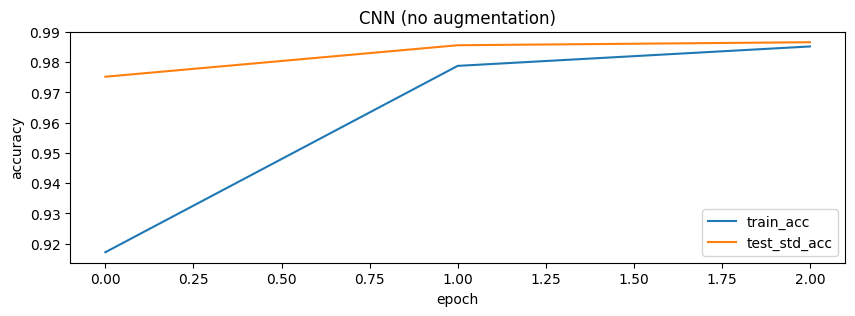

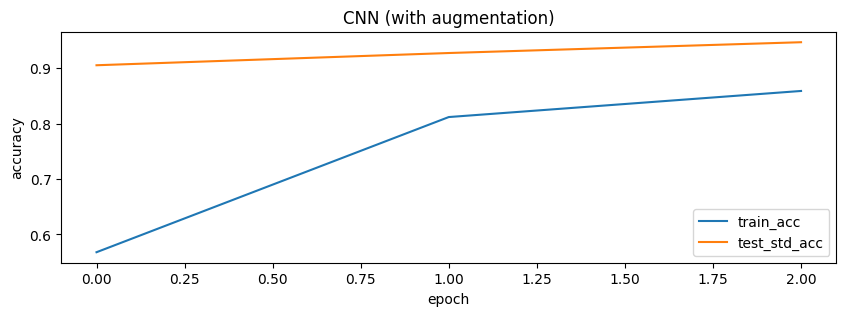

In [12]:
def plot_hist(hist, title):
    plt.figure(figsize=(10, 3))
    plt.plot(hist["train_acc"], label="train_acc")
    plt.plot(hist["val_acc"], label="test_std_acc")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()
    plt.show()

plot_hist(hist_noaug, "CNN (no augmentation)")
plot_hist(hist_aug, "CNN (with augmentation)")


## 9) Visualizing CNN layers

We will look at:
1. **First-layer convolution filters** (weights of Conv1)
2. **Feature maps (activations)** for a single image

This helps you *see* what the CNN learns.


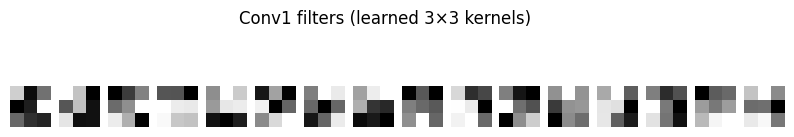

In [13]:
def show_conv1_filters(model, max_filters=16):
    conv1 = None
    for layer in model.features:
        if isinstance(layer, nn.Conv2d):
            conv1 = layer
            break
    W = conv1.weight.detach().cpu()  # (out_channels, in_channels, kH, kW)

    n = min(W.shape[0], max_filters)
    plt.figure(figsize=(10, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(W[i, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle("Conv1 filters (learned 3×3 kernels)")
    plt.show()

show_conv1_filters(cnn_aug)


### Feature maps (activations)

We take **one test image**, pass it through the CNN, and visualize outputs after each convolution layer.


In [14]:
@torch.no_grad()
def get_activations(model, x):
    activations = []
    cur = x
    for layer in model.features:
        cur = layer(cur)
        if isinstance(layer, nn.Conv2d):
            activations.append(cur.detach().cpu())
    return activations

# One sample from the standard test set
img, label = test_std[0]
x = img.unsqueeze(0).to(device)

acts = get_activations(cnn_aug, x)

print("Label:", label)
print("Activation shapes:", [a.shape for a in acts])


Label: 7
Activation shapes: [torch.Size([1, 16, 28, 28]), torch.Size([1, 32, 14, 14])]


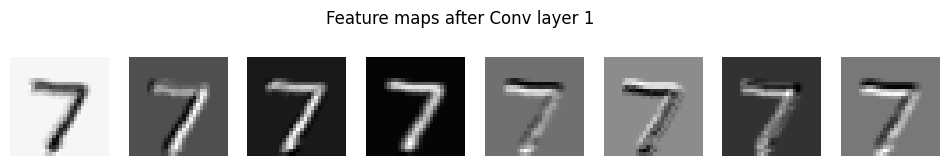

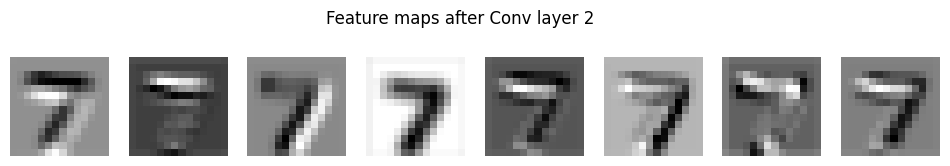

In [15]:
def show_feature_maps(activation, title, max_maps=8):
    C = activation.shape[1]
    n = min(C, max_maps)
    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(activation[0, i], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

for idx, act in enumerate(acts, start=1):
    show_feature_maps(act, f"Feature maps after Conv layer {idx}", max_maps=8)


## 10) Final reflection

1. Compare **standard test accuracy** vs **transformed test accuracy** for both models. What do you notice?
Le modèle sans augmentation obtient une très bonne précision sur le test standard, mais sa performance chute fortement sur le test transformé. À l’inverse, le modèle entraîné avec augmentation conserve une précision élevée sur le test transformé, même si sa performance sur le test standard est légèrement plus faible.
2. Why does augmentation help on the transformed test set?
L’augmentation expose le modèle, dès l’entraînement, à des rotations et des translations similaires à celles du test transformé. Le réseau apprend ainsi des invariances géométriques et devient plus robuste aux variations de position et d’orientation des chiffres.
3. Do we always expect augmentation to improve standard test accuracy? Why/why not?
Non, l’augmentation n’améliore pas toujours la précision sur le test standard. En rendant les données d’entraînement plus difficiles et plus variées, elle peut empêcher le modèle d’optimiser parfaitement la reconnaissance de données propres et centrées.

**Conclusion:** In the next LAB(2), we will go deeper into CNN architectures, and you should see further accuracy improvements.
